## Test plots for LQG Control Model

In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from model.lqg_control_model import LQGController, LQGParams, Perturbation
import model_utils

%matplotlib inline

### Initialize LQG Controller and Parameters

In [3]:
# Initialize parameters and controller
params = LQGParams()
controller = LQGController(params)

# Create basis functions and feedforward weights
Phi = controller.make_default_basis(n_basis=8, width=10.0)
ff_weights = controller.make_default_ff_weights(n_basis=8)

print(f"Target: {params.target}")
print(f"Number of basis functions: {Phi.shape[1]}")

Target: [1.  0.5 0.  0. ]
Number of basis functions: 8


### 1. Baseline LQG Control Reach (No Perturbation)

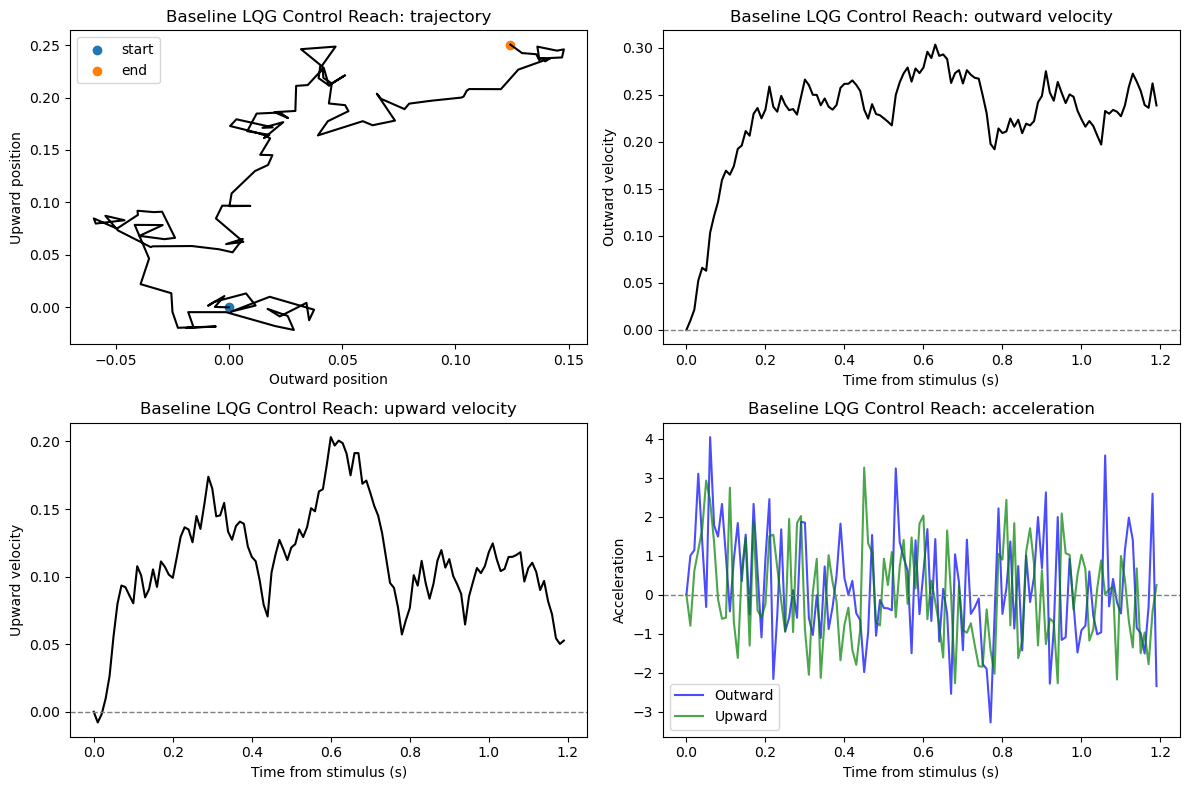

In [4]:
# Simulate baseline reach without perturbation
baseline = controller.simulate_reach(
    Phi=Phi,
    ff_weights=ff_weights,
    perturbation=None,
    rng=np.random.default_rng(0)
)

# Plot baseline reach
model_utils.plot_reach(baseline, title="Baseline LQG Control Reach", params=params)

### 2. Mossy Fiber Perturbation

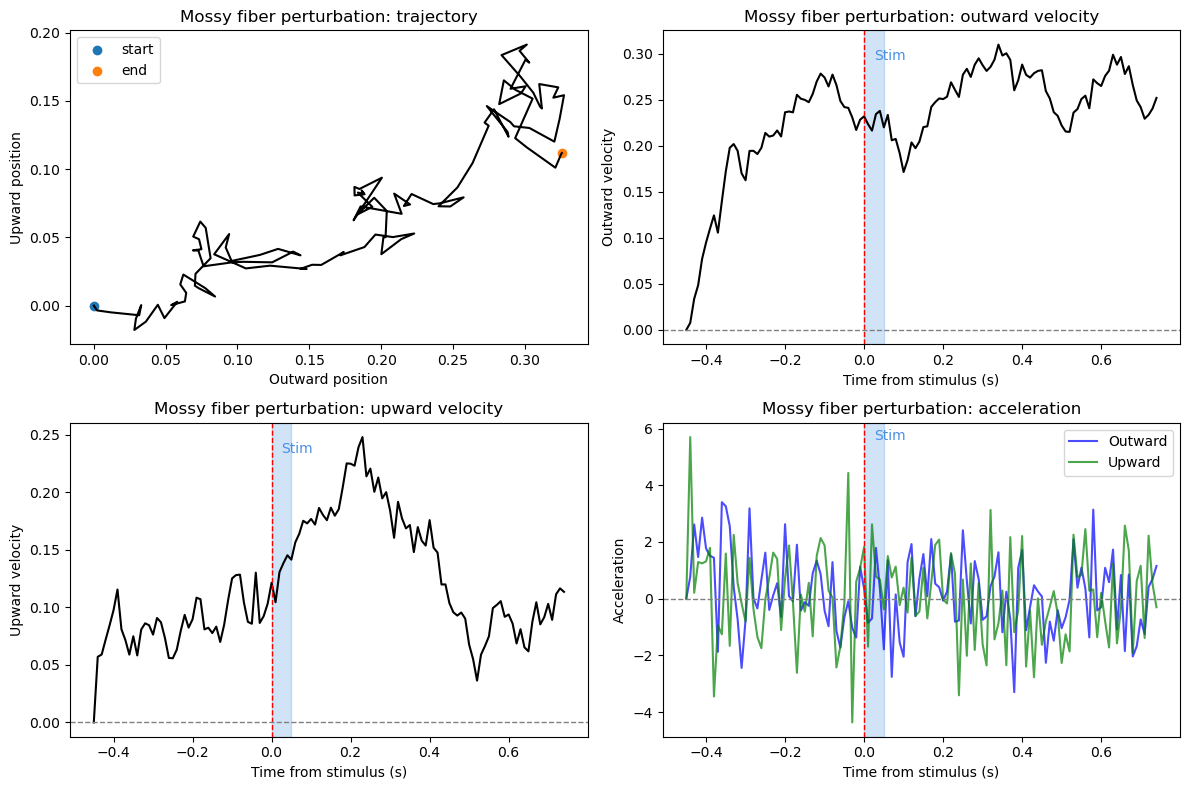

In [5]:
# Define mossy fiber perturbation
mossy_pert = Perturbation(
    kind='mossy',
    onset_idx=45,
    duration=5,
    observer_bias=np.array([0.0, 0.0, 0.9, 0.5])
)

# Simulate reach with mossy fiber perturbation
res_mossy = controller.simulate_reach(
    Phi=Phi,
    ff_weights=ff_weights,
    perturbation=mossy_pert,
    rng=np.random.default_rng(3)
)

# Plot mossy fiber perturbation reach
model_utils.plot_reach(res_mossy, perturbation=mossy_pert, title="Mossy fiber perturbation", params=params)

### 3. General IntA Perturbation

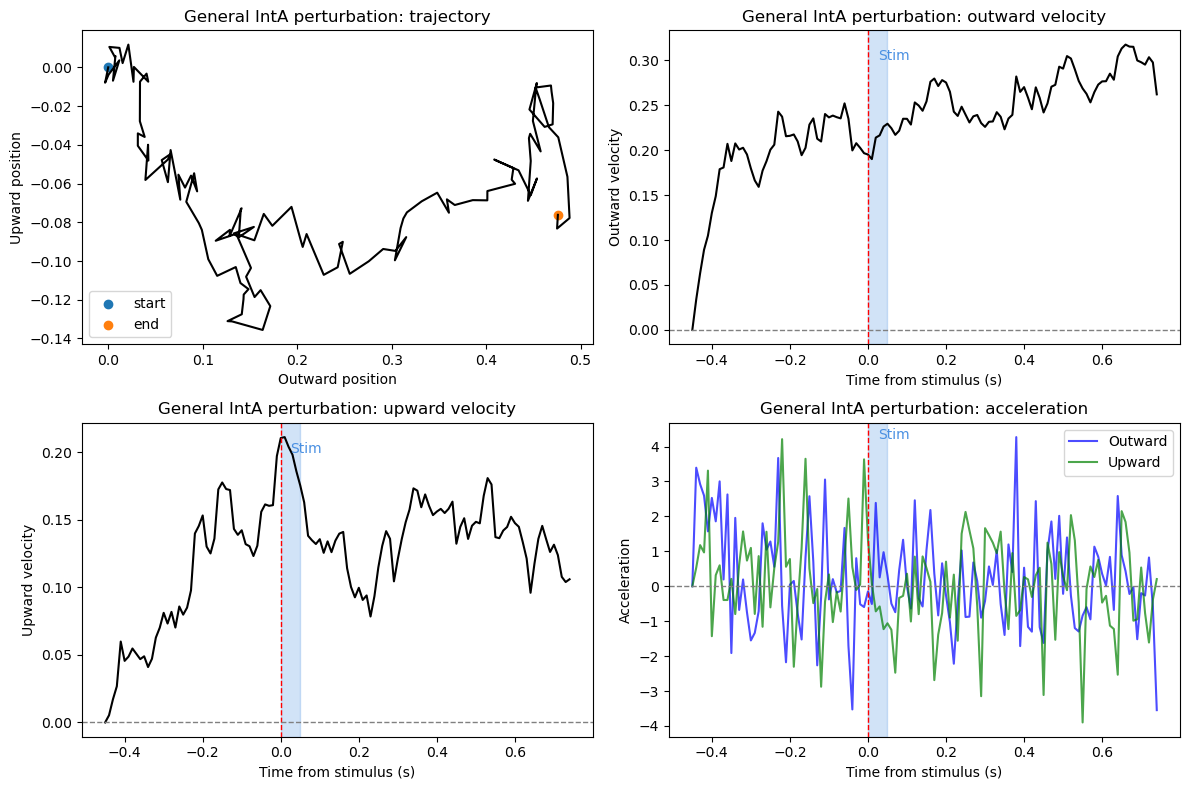

In [6]:
# Define general IntA perturbation
inta_general_pert = Perturbation(
    kind='inta_general',
    onset_idx=45,
    duration=5,
    pulse=np.array([-2.2, -1.0])
)

# Simulate reach with general IntA perturbation
res_inta_general = controller.simulate_reach(
    Phi=Phi,
    ff_weights=ff_weights,
    perturbation=inta_general_pert,
    rng=np.random.default_rng(2)
)

# Plot general IntA perturbation reach
model_utils.plot_reach(res_inta_general, perturbation=inta_general_pert, title="General IntA perturbation", params=params)

### 4. IntA→RN Perturbation

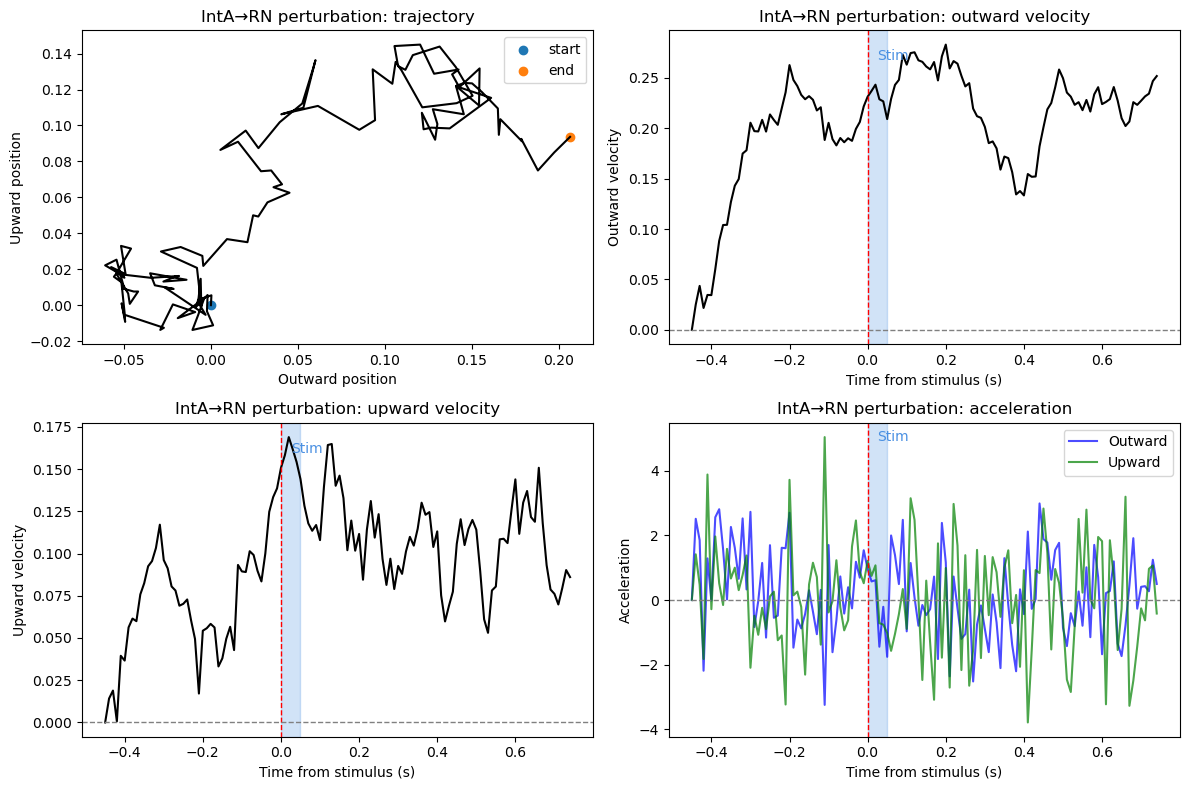

In [7]:
# Define IntA→RN perturbation
inta_rn_pert = Perturbation(
    kind='inta_rn',
    onset_idx=45,
    duration=5,
    pulse=np.array([-2.2, -1.0])
)

# Simulate reach with IntA→RN perturbation
res_inta_rn = controller.simulate_reach(
    Phi=Phi,
    ff_weights=ff_weights,
    perturbation=inta_rn_pert,
    rng=np.random.default_rng(1)
)

# Plot IntA→RN perturbation reach
model_utils.plot_reach(res_inta_rn, perturbation=inta_rn_pert, title="IntA→RN perturbation", params=params)

### 5. Behavior Summary Metrics

In [9]:
# behavior metrics for all conditions
print("Baseline Metrics:")
baseline_metrics = model_utils.compute_behavior_metrics(baseline, params.target)
for key, value in baseline_metrics.items():
    print(f"  {key}: {value:.4f}")

print("\nIntA→RN Perturbation Metrics:")
inta_rn_metrics = model_utils.compute_behavior_metrics(res_inta_rn, params.target)
for key, value in inta_rn_metrics.items():
    print(f"  {key}: {value:.4f}")

print("\nGeneral IntA Perturbation Metrics:")
inta_general_metrics = model_utils.compute_behavior_metrics(res_inta_general, params.target)
for key, value in inta_general_metrics.items():
    print(f"  {key}: {value:.4f}")

print("\nMossy Fiber Perturbation Metrics:")
mossy_metrics = model_utils.compute_behavior_metrics(res_mossy, params.target)
for key, value in mossy_metrics.items():
    print(f"  {key}: {value:.4f}")

Baseline Metrics:
  endpoint_error: 0.9106
  peak_outward_vel: 0.3032
  min_outward_vel: 0.0000
  rebound_magnitude: 0.3032
  rebound_idx: 63.0000
  peak_innovation: 0.1077
  cost_J: 33638.9533

IntA→RN Perturbation Metrics:
  endpoint_error: 0.8915
  peak_outward_vel: 0.2827
  min_outward_vel: 0.0000
  rebound_magnitude: 0.2827
  rebound_idx: 65.0000
  peak_innovation: 0.1149
  cost_J: 33780.6914

General IntA Perturbation Metrics:
  endpoint_error: 0.7789
  peak_outward_vel: 0.3173
  min_outward_vel: 0.0000
  rebound_magnitude: 0.3173
  rebound_idx: 111.0000
  peak_innovation: 0.1049
  cost_J: 31264.5455

Mossy Fiber Perturbation Metrics:
  endpoint_error: 0.7780
  peak_outward_vel: 0.3099
  min_outward_vel: 0.0000
  rebound_magnitude: 0.3099
  rebound_idx: 79.0000
  peak_innovation: 1.0569
  cost_J: 30258.7083
